In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
        ConfusionMatrixDisplay,
        accuracy_score,
        classification_report,
        confusion_matrix,
        f1_score
    )
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [ ]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-3
NUM_CLASSES = 5
NUM_WORKERS = 4
SEED = 42

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

torch.manual_seed(SEED)

In [ ]:
# resize -> center crop -> ImageNet normalization
weights = models.ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()

train_ds = datasets.ImageFolder("flower-splits/train", transform=preprocess)
val_ds   = datasets.ImageFolder("flower-splits/val",   transform=preprocess)
test_ds  = datasets.ImageFolder("flower-splits/test",  transform=preprocess)

labels = train_ds.classes

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=False,
                      persistent_workers=NUM_WORKERS > 0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=False,
                      persistent_workers=NUM_WORKERS > 0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=False,
                      persistent_workers=NUM_WORKERS > 0)

In [ ]:
class FlowerNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
def predict_classes(model, x):
    model.eval()
    with torch.no_grad():
        logits = model(x.to(device))
        return logits.argmax(dim=1)

In [ ]:
def evaluate(model, dl, labels):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")

    all_preds, all_targets = [], []
    total_loss, total_count = 0.0, 0

    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item()
            total_count += y.size(0)
            all_preds.append(logits.argmax(dim=1).cpu())
            all_targets.append(y.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    return {
        "loss":     total_loss / total_count,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "cm":       confusion_matrix(y_true, y_pred),
        "report":   classification_report(y_true, y_pred,
                                          target_names=labels,
                                          digits=4, zero_division=0),
    }


# Sanity check: evaluate runs end-to-end on a freshly-instantiated model.
# Pretrained backbone + random head -> predictions should be ~chance (~20%).
# Guarded so DataLoader workers don't re-run training when they re-import this file.
if __name__ == "__main__":
    _sanity = FlowerNet().to(device)
    _metrics = evaluate(_sanity, val_dl, labels)
    print(f"[sanity] untrained val: acc={_metrics['accuracy']:.4f} "
          f"macro_f1={_metrics['macro_f1']:.4f} loss={_metrics['loss']:.4f}")
    del _sanity

[sanity] untrained val: acc=0.1782 macro_f1=0.1577 loss=1.6153


In [ ]:
def infinite_iter(dl):
    while True:
        for item in dl:
            yield item

def train(model, optimizer, train_dl, val_dl, num_epochs, name):
    criterion = nn.CrossEntropyLoss()
    out_dir = Path("runs") / name
    out_dir.mkdir(parents=True, exist_ok=True)

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   [], "val_macro_f1": []}
    best_val_f1 = -1.0

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0

        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss    += loss.item() * y.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_total   += y.size(0)

        train_loss = running_loss    / running_total
        train_acc  = running_correct / running_total
        val = evaluate(model, val_dl, labels)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val["loss"])
        history["val_acc"].append(val["accuracy"])
        history["val_macro_f1"].append(val["macro_f1"])

        print(f"[{name}] epoch {epoch}/{num_epochs}  "
              f"train: loss={train_loss:.4f} acc={train_acc:.4f}  |  "
              f"val: loss={val['loss']:.4f} acc={val['accuracy']:.4f} "
              f"f1={val['macro_f1']:.4f}")

        if val["macro_f1"] > best_val_f1:
            best_val_f1 = val["macro_f1"]
            torch.save(model.state_dict(), out_dir / "best.pt")

    torch.save(model.state_dict(), out_dir / "last.pt")
    with open(out_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2)

    return history

In [ ]:
if __name__ == "__main__":
    model = FlowerNet().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    baseline_history = train(model, optimizer, train_dl, val_dl,
                             num_epochs=NUM_EPOCHS, name="baseline")

[baseline] epoch 1/10  train: loss=0.6295 acc=0.7860  |  val: loss=0.4457 acc=0.8565 f1=0.8555
[baseline] epoch 2/10  train: loss=0.3655 acc=0.8772  |  val: loss=0.4814 acc=0.8588 f1=0.8564
[baseline] epoch 3/10  train: loss=0.2610 acc=0.9115  |  val: loss=0.3656 acc=0.8623 f1=0.8615
[baseline] epoch 4/10  train: loss=0.2313 acc=0.9235  |  val: loss=0.4285 acc=0.8611 f1=0.8565
[baseline] epoch 5/10  train: loss=0.1522 acc=0.9463  |  val: loss=0.3689 acc=0.8889 f1=0.8890
[baseline] epoch 6/10  train: loss=0.1115 acc=0.9656  |  val: loss=0.5489 acc=0.8194 f1=0.8171
[baseline] epoch 7/10  train: loss=0.1021 acc=0.9652  |  val: loss=0.4620 acc=0.8519 f1=0.8507
[baseline] epoch 8/10  train: loss=0.0978 acc=0.9691  |  val: loss=0.4397 acc=0.8600 f1=0.8579
[baseline] epoch 9/10  train: loss=0.0861 acc=0.9726  |  val: loss=0.3994 acc=0.8553 f1=0.8532
[baseline] epoch 10/10  train: loss=0.0896 acc=0.9730  |  val: loss=0.4377 acc=0.8657 f1=0.8655


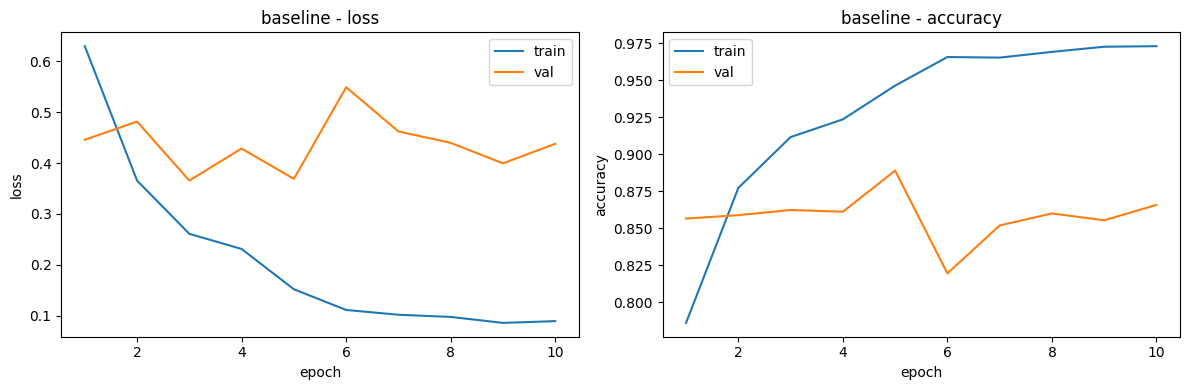


=== baseline / train ===
loss=0.0865  acc=0.9741  macro_f1=0.9742
              precision    recall  f1-score   support

       daisy     0.9910    0.9629    0.9767       458
   dandelion     0.9904    0.9778    0.9841       631
        rose     0.9297    0.9851    0.9566       470
   sunflower     0.9931    0.9818    0.9874       440
       tulip     0.9677    0.9644    0.9660       590

    accuracy                         0.9741      2589
   macro avg     0.9744    0.9744    0.9742      2589
weighted avg     0.9748    0.9741    0.9742      2589



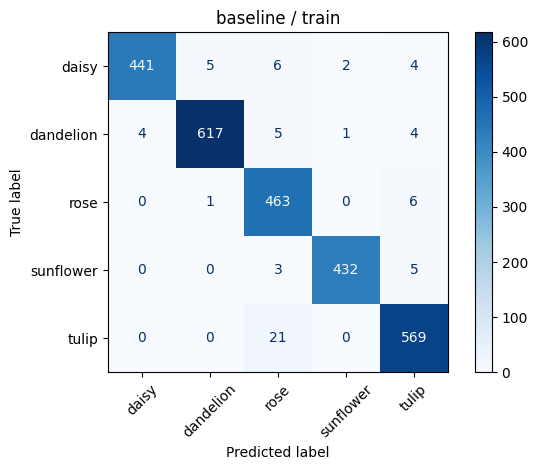


=== baseline / val ===
loss=0.3689  acc=0.8889  macro_f1=0.8890
              precision    recall  f1-score   support

       daisy     0.9420    0.8497    0.8935       153
   dandelion     0.9505    0.9143    0.9320       210
        rose     0.7923    0.9236    0.8529       157
   sunflower     0.9481    0.8707    0.9078       147
       tulip     0.8398    0.8782    0.8586       197

    accuracy                         0.8889       864
   macro avg     0.8946    0.8873    0.8890       864
weighted avg     0.8946    0.8889    0.8900       864



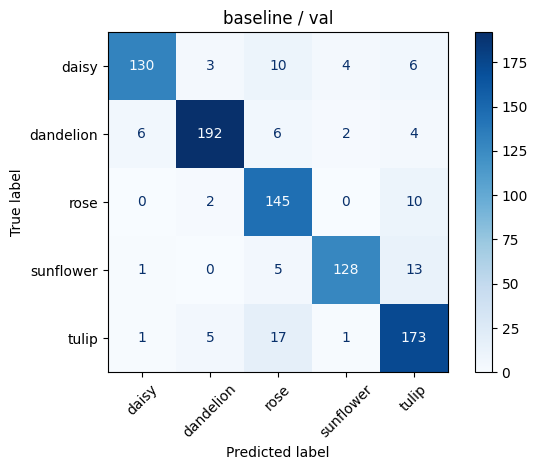


=== baseline / test ===
loss=0.4404  acc=0.8669  macro_f1=0.8637
              precision    recall  f1-score   support

       daisy     0.9274    0.7516    0.8303       153
   dandelion     0.9286    0.9242    0.9264       211
        rose     0.7619    0.9172    0.8324       157
   sunflower     0.8776    0.8836    0.8805       146
       tulip     0.8557    0.8426    0.8491       197

    accuracy                         0.8669       864
   macro avg     0.8702    0.8638    0.8637       864
weighted avg     0.8728    0.8669    0.8669       864



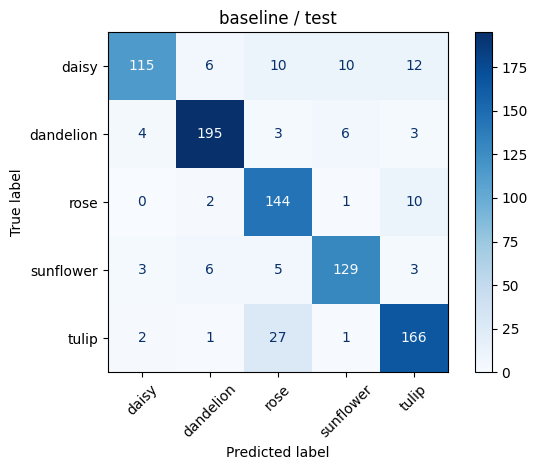

In [ ]:
def plot_history(history, name):
    """Save train/val loss + accuracy curves to runs/<name>/curves.png."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    ax_loss.plot(epochs, history["train_loss"], label="train")
    ax_loss.plot(epochs, history["val_loss"],   label="val")
    ax_loss.set(xlabel="epoch", ylabel="loss", title=f"{name} - loss")
    ax_loss.legend()

    ax_acc.plot(epochs, history["train_acc"], label="train")
    ax_acc.plot(epochs, history["val_acc"],   label="val")
    ax_acc.set(xlabel="epoch", ylabel="accuracy", title=f"{name} - accuracy")
    ax_acc.legend()

    fig.tight_layout()
    fig.savefig(Path("runs") / name / "curves.png", dpi=120, bbox_inches="tight")
    plt.show()

def full_eval(model, name, dls=None):
    """Report loss/accuracy/macro-F1 + classification report on all splits."""
    if dls is None:
        dls = [("train", train_dl), ("val", val_dl), ("test", test_dl)]
    for split_name, dl in dls:
        m = evaluate(model, dl, labels)
        print(f"\n=== {name} / {split_name} ===")
        print(f"loss={m['loss']:.4f}  acc={m['accuracy']:.4f}  "
              f"macro_f1={m['macro_f1']:.4f}")
        print(m["report"])
        disp = ConfusionMatrixDisplay(confusion_matrix=m["cm"],
                                      display_labels=labels)
        disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
        plt.title(f"{name} / {split_name}")
        plt.tight_layout()
        plt.show()

# Reload the best checkpoint (highest val macro-F1) for reporting.
if __name__ == "__main__":
    model.load_state_dict(torch.load("runs/baseline/best.pt", map_location=device))
    plot_history(baseline_history, "baseline")
    full_eval(model, "baseline")

In [ ]:
# Reuse the matched preprocessing's crop size + normalization so the augmented
# pipeline ends in the exact same value range the pretrained backbone expects.
train_aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(preprocess.crop_size[0], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=preprocess.mean, std=preprocess.std),
])

train_aug_ds = datasets.ImageFolder("flower-splits/train",
                                    transform=train_aug_transform)
train_aug_dl = DataLoader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False,
                          persistent_workers=NUM_WORKERS > 0)

if __name__ == "__main__":
    model_aug = FlowerNet().to(device)
    optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=LR)
    aug_history = train(model_aug, optimizer_aug, train_aug_dl, val_dl,
                        num_epochs=NUM_EPOCHS * 2, name="aug")

[aug] epoch 1/20  train: loss=0.6484 acc=0.7798  |  val: loss=0.4800 acc=0.8403 f1=0.8353
[aug] epoch 2/20  train: loss=0.4668 acc=0.8358  |  val: loss=0.5502 acc=0.8160 f1=0.8135
[aug] epoch 3/20  train: loss=0.3521 acc=0.8756  |  val: loss=0.4602 acc=0.8542 f1=0.8551
[aug] epoch 4/20  train: loss=0.3363 acc=0.8911  |  val: loss=0.5080 acc=0.8194 f1=0.8151
[aug] epoch 5/20  train: loss=0.2802 acc=0.9031  |  val: loss=0.3279 acc=0.8738 f1=0.8728
[aug] epoch 6/20  train: loss=0.2475 acc=0.9131  |  val: loss=0.4477 acc=0.8588 f1=0.8580
[aug] epoch 7/20  train: loss=0.2495 acc=0.9135  |  val: loss=0.4053 acc=0.8889 f1=0.8906
[aug] epoch 8/20  train: loss=0.2387 acc=0.9115  |  val: loss=0.4909 acc=0.8669 f1=0.8628
[aug] epoch 9/20  train: loss=0.1767 acc=0.9355  |  val: loss=0.6282 acc=0.8218 f1=0.8202
[aug] epoch 10/20  train: loss=0.2187 acc=0.9262  |  val: loss=0.4275 acc=0.8669 f1=0.8670
[aug] epoch 11/20  train: loss=0.1635 acc=0.9436  |  val: loss=0.5093 acc=0.8345 f1=0.8255
[aug] ep

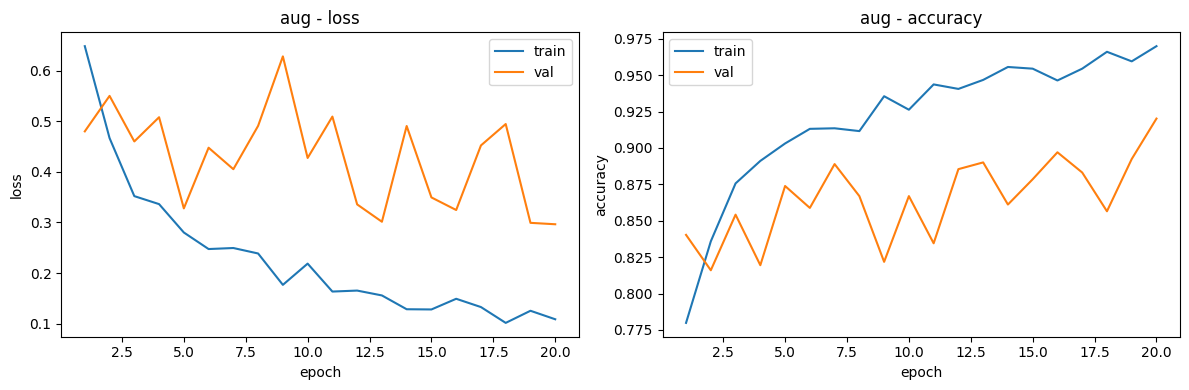


=== aug / train ===
loss=0.0822  acc=0.9699  macro_f1=0.9702
              precision    recall  f1-score   support

       daisy     0.9932    0.9563    0.9744       458
   dandelion     0.9717    0.9794    0.9755       631
        rose     0.9316    0.9851    0.9576       470
   sunflower     0.9776    0.9909    0.9842       440
       tulip     0.9772    0.9424    0.9594       590

    accuracy                         0.9699      2589
   macro avg     0.9702    0.9708    0.9702      2589
weighted avg     0.9705    0.9699    0.9699      2589



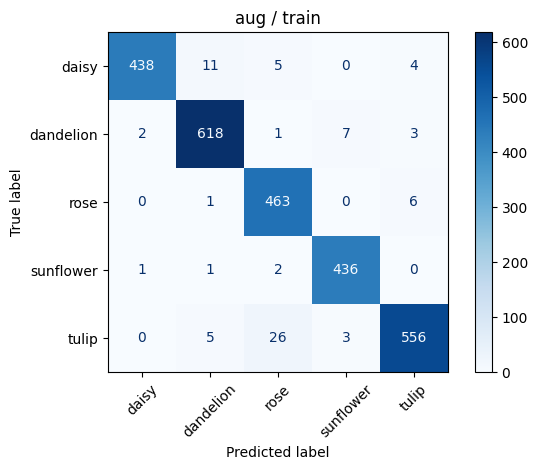


=== aug / val ===
loss=0.2965  acc=0.9201  macro_f1=0.9197
              precision    recall  f1-score   support

       daisy     0.9784    0.8889    0.9315       153
   dandelion     0.9234    0.9762    0.9491       210
        rose     0.8655    0.9427    0.9024       157
   sunflower     0.9371    0.9116    0.9241       147
       tulip     0.9101    0.8731    0.8912       197

    accuracy                         0.9201       864
   macro avg     0.9229    0.9185    0.9197       864
weighted avg     0.9219    0.9201    0.9200       864



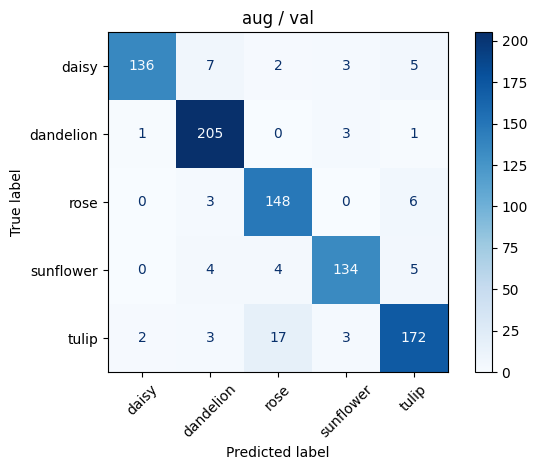


=== aug / test ===
loss=0.3596  acc=0.8981  macro_f1=0.8971
              precision    recall  f1-score   support

       daisy     0.9688    0.8105    0.8826       153
   dandelion     0.8899    0.9573    0.9224       211
        rose     0.8033    0.9363    0.8647       157
   sunflower     0.9306    0.9178    0.9241       146
       tulip     0.9286    0.8579    0.8918       197

    accuracy                         0.8981       864
   macro avg     0.9042    0.8960    0.8971       864
weighted avg     0.9038    0.8981    0.8982       864



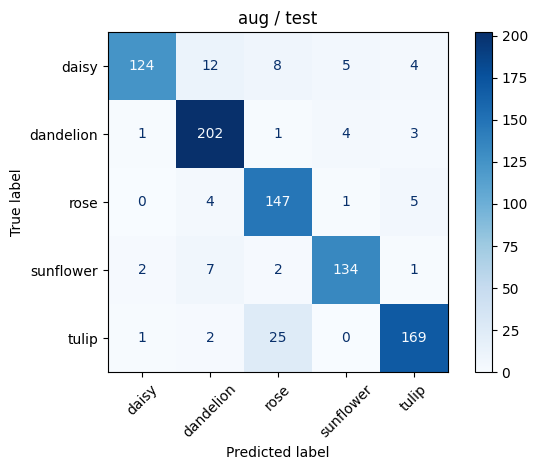

In [ ]:
if __name__ == "__main__":
    model_aug.load_state_dict(torch.load("runs/aug/best.pt", map_location=device))
    plot_history(aug_history, "aug")
    full_eval(model_aug, "aug")

In [ ]:
# Swap the backbone family entirely: EfficientNet-B0 (~5M params, mobile-inverted
# bottlenecks) vs ResNet50 (~25M params, residual conv blocks). Same ImageNet
# pretraining, but its weights ship with their own resize/crop and normalization
# stats, so we build matched train/eval transforms for it.
class FlowerNetEffNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

effnet_weights    = models.EfficientNet_B0_Weights.IMAGENET1K_V1
effnet_preprocess = effnet_weights.transforms()

train_effnet_transform = transforms.Compose([
    transforms.RandomResizedCrop(effnet_preprocess.crop_size[0], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=effnet_preprocess.mean, std=effnet_preprocess.std),
])

train_effnet_ds = datasets.ImageFolder("flower-splits/train",
                                       transform=train_effnet_transform)
val_effnet_ds   = datasets.ImageFolder("flower-splits/val",
                                       transform=effnet_preprocess)
test_effnet_ds  = datasets.ImageFolder("flower-splits/test",
                                       transform=effnet_preprocess)

train_effnet_dl = DataLoader(train_effnet_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=False,
                             persistent_workers=NUM_WORKERS > 0)
val_effnet_dl   = DataLoader(val_effnet_ds,   batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=False,
                             persistent_workers=NUM_WORKERS > 0)
test_effnet_dl  = DataLoader(test_effnet_ds,  batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=False,
                             persistent_workers=NUM_WORKERS > 0)

In [ ]:
if __name__ == "__main__":
    model_effnet     = FlowerNetEffNet().to(device)
    optimizer_effnet = torch.optim.Adam(model_effnet.parameters(), lr=LR)
    effnet_history   = train(model_effnet, optimizer_effnet,
                             train_effnet_dl, val_effnet_dl,
                             num_epochs=NUM_EPOCHS * 2, name="effnet")

[effnet] epoch 1/20  train: loss=0.5175 acc=0.8262  |  val: loss=0.2876 acc=0.8970 f1=0.8967
[effnet] epoch 2/20  train: loss=0.2873 acc=0.9042  |  val: loss=0.2913 acc=0.9016 f1=0.9022
[effnet] epoch 3/20  train: loss=0.2698 acc=0.9150  |  val: loss=0.2861 acc=0.8993 f1=0.8951
[effnet] epoch 4/20  train: loss=0.2081 acc=0.9285  |  val: loss=0.2297 acc=0.9294 f1=0.9286
[effnet] epoch 5/20  train: loss=0.1767 acc=0.9413  |  val: loss=0.2480 acc=0.9132 f1=0.9112
[effnet] epoch 6/20  train: loss=0.1240 acc=0.9583  |  val: loss=0.3560 acc=0.9028 f1=0.9016
[effnet] epoch 7/20  train: loss=0.1298 acc=0.9564  |  val: loss=0.3225 acc=0.9028 f1=0.9015
[effnet] epoch 8/20  train: loss=0.1960 acc=0.9347  |  val: loss=0.2815 acc=0.9190 f1=0.9178
[effnet] epoch 9/20  train: loss=0.1060 acc=0.9672  |  val: loss=0.3836 acc=0.9051 f1=0.9020
[effnet] epoch 10/20  train: loss=0.1520 acc=0.9509  |  val: loss=0.2170 acc=0.9236 f1=0.9225
[effnet] epoch 11/20  train: loss=0.0791 acc=0.9730  |  val: loss=0.2

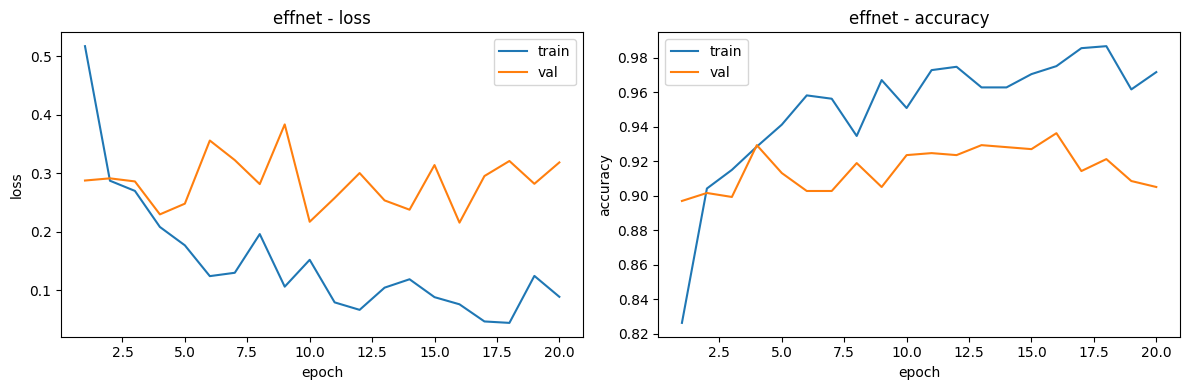


=== effnet / train ===
loss=0.0117  acc=0.9969  macro_f1=0.9969
              precision    recall  f1-score   support

       daisy     0.9978    0.9956    0.9967       458
   dandelion     0.9968    0.9984    0.9976       631
        rose     0.9957    0.9936    0.9947       470
   sunflower     0.9977    1.0000    0.9989       440
       tulip     0.9966    0.9966    0.9966       590

    accuracy                         0.9969      2589
   macro avg     0.9969    0.9969    0.9969      2589
weighted avg     0.9969    0.9969    0.9969      2589



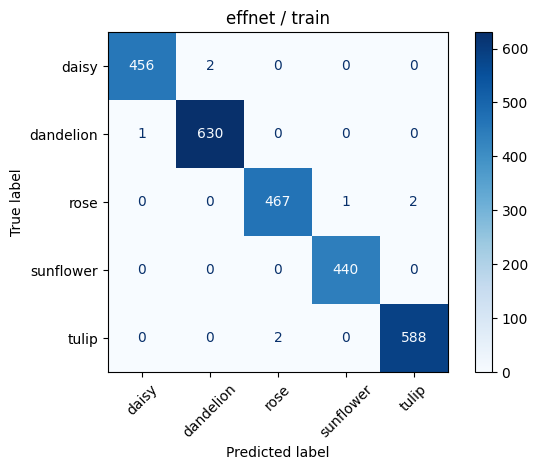


=== effnet / val ===
loss=0.2155  acc=0.9363  macro_f1=0.9357
              precision    recall  f1-score   support

       daisy     0.9660    0.9281    0.9467       153
   dandelion     0.9710    0.9571    0.9640       210
        rose     0.9338    0.8981    0.9156       157
   sunflower     0.9267    0.9456    0.9360       147
       tulip     0.8900    0.9442    0.9163       197

    accuracy                         0.9363       864
   macro avg     0.9375    0.9346    0.9357       864
weighted avg     0.9373    0.9363    0.9365       864



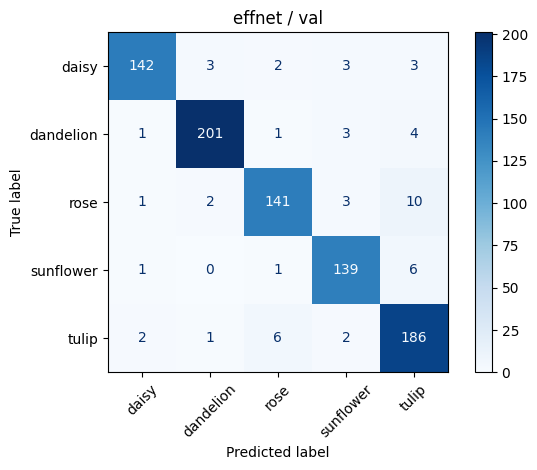


=== effnet / test ===
loss=0.2063  acc=0.9317  macro_f1=0.9303
              precision    recall  f1-score   support

       daisy     0.9580    0.8954    0.9257       153
   dandelion     0.9710    0.9526    0.9617       211
        rose     0.8743    0.9299    0.9012       157
   sunflower     0.9156    0.9658    0.9400       146
       tulip     0.9326    0.9137    0.9231       197

    accuracy                         0.9317       864
   macro avg     0.9303    0.9315    0.9303       864
weighted avg     0.9330    0.9317    0.9319       864



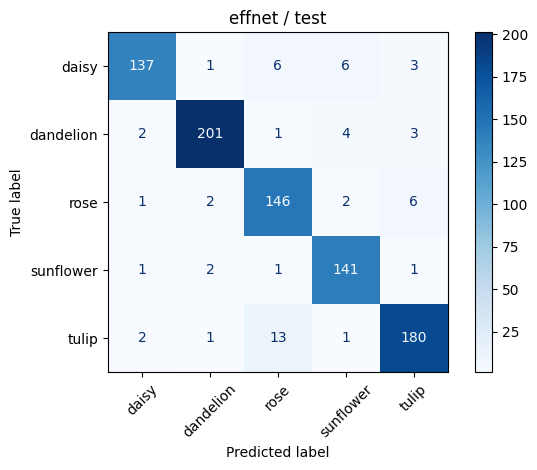

In [ ]:
if __name__ == "__main__":
    model_effnet.load_state_dict(torch.load("runs/effnet/best.pt",
                                            map_location=device))
    plot_history(effnet_history, "effnet")
    full_eval(model_effnet, "effnet",
              dls=[("train", train_effnet_dl),
                   ("val",   val_effnet_dl),
                   ("test",  test_effnet_dl)])